# Project Phase 2 - Data Preparation (MSD 10K Subset)

This notebook follows CRISP-DM data preparation tasks for the Million Song Dataset 10K subset.

Rubric coverage in this notebook:
- EDA operations (3+) with visualizations
- Clear explanation before each code block
- Pearson correlation definition and heat map with interpretation
- Missing value handling
- Class imbalance handling (oversampling)
- Feature engineering (scaling + categorical conversion)
- Training-test split
- K-fold cross-validation

## 1. Import Libraries
This block imports libraries used for data extraction, wrangling, visualization, and model validation.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import h5py

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from imblearn.over_sampling import RandomOverSampler

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)

## 2. Extract Structured Data from MSD HDF5 Files
Each song is stored in an HDF5 file. This block extracts a compact table with track metadata and core audio attributes needed for data preparation and modeling.

In [2]:
BASE_DIR = Path('MillionSongSubset')
h5_files = sorted(BASE_DIR.rglob('*.h5'))
print(f'Total HDF5 files found: {len(h5_files)}')

def to_text(value):
    if isinstance(value, (bytes, np.bytes_)):
        return value.decode('utf-8', errors='ignore').strip()
    return value

rows = []

for fp in h5_files:
    with h5py.File(fp, 'r') as h5:
        meta = h5['metadata']['songs'][0]
        ana = h5['analysis']['songs'][0]
        mb = h5['musicbrainz']['songs'][0]

        row = {
            'file_path': str(fp),
            'song_id': to_text(meta['song_id']),
            'track_id': to_text(ana['track_id']),
            'artist_name': to_text(meta['artist_name']),
            'title': to_text(meta['title']),
            'release': to_text(meta['release']),
            'genre': to_text(meta['genre']),
            'year': int(mb['year']),
            'artist_hotttnesss': float(meta['artist_hotttnesss']),
            'song_hotttnesss': float(meta['song_hotttnesss']),
            'artist_familiarity': float(meta['artist_familiarity']),
            'duration': float(ana['duration']),
            'tempo': float(ana['tempo']),
            'loudness': float(ana['loudness']),
            'key': int(ana['key']),
            'key_confidence': float(ana['key_confidence']),
            'mode': int(ana['mode']),
            'mode_confidence': float(ana['mode_confidence']),
            'time_signature': int(ana['time_signature']),
            'time_signature_confidence': float(ana['time_signature_confidence']),
            'danceability': float(ana['danceability']),
            'energy': float(ana['energy'])
        }

        rows.append(row)

df = pd.DataFrame(rows)
print(df.shape)
df.head()

Total HDF5 files found: 10000
(10000, 22)


,file_path,song_id,track_id,artist_name,title,release,genre,year,artist_hotttnesss,song_hotttnesss,artist_familiarity,duration,tempo,loudness,key,key_confidence,mode,mode_confidence,time_signature,time_signature_confidence,danceability,energy
0,MillionSongSubset/A/A/A/TRAAAAW128F429D538.h5,SOMZWCG12A8C13C480,TRAAAAW128F429D538,Casual,I Didn't Mean To,Fear Itself,,0,0.401998,0.602120,0.581794,218.93179,92.198,-11.197,1,0.736,0,0.636,4,0.778,0.0,0.0
1,MillionSongSubset/A/A/A/TRAAABD128F429CF47.h5,SOCIWDW12A8C13D406,TRAAABD128F429CF47,The Box Tops,Soul Deep,Dimensions,,1969,0.417500,NaN,0.630630,148.03546,121.274,-9.843,6,0.169,0,0.430,4,0.384,0.0,0.0
2,MillionSongSubset/A/A/A/TRAAADZ128F9348C2E.h5,SOXVLOJ12AB0189215,TRAAADZ128F9348C2E,Sonora Santanera,Amor De Cabaret,Las Numero 1 De La Sonora Santanera,,0,0.343428,NaN,0.487357,177.47546,100.070,-9.689,8,0.643,1,0.565,1,0.000,0.0,0.0
3,MillionSongSubset/A/A/A/TRAAAEF128F4273421.h5,SONHOTT12A8C13493C,TRAAAEF128F4273421,Adam Ant,Something Girls,Friend Or Foe,,1982,0.454231,NaN,0.630382,233.40363,119.293,-9.013,0,0.751,1,0.749,4,0.000,0.0,0.0
4,MillionSongSubset/A/A/A/TRAAAFD128F92F423A.h5,SOFSOCN12A8C143F5D,TRAAAFD128F92F423A,Gob,Face the Ashes,Muertos Vivos,,2007,0.401724,0.604501,0.651046,209.60608,129.738,-4.501,2,0.092,1,0.371,4,0.562,0.0,0.0


## 3. Initial Data Audit
This block checks schema, data types, duplicate IDs, and summary statistics to identify anomalies before cleaning.

In [3]:
print('DataFrame info:')
print(df.info())

print('\nDuplicate song_id count:', df['song_id'].duplicated().sum())
print('Duplicate track_id count:', df['track_id'].duplicated().sum())

numeric_cols = df.select_dtypes(include=['number']).columns
display(df[numeric_cols].describe().T)

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   file_path                  10000 non-null  object 
 1   song_id                    10000 non-null  object 
 2   track_id                   10000 non-null  object 
 3   artist_name                10000 non-null  object 
 4   title                      10000 non-null  object 
 5   release                    10000 non-null  object 
 6   genre                      10000 non-null  object 
 7   year                       10000 non-null  int64  
 8   artist_hotttnesss          10000 non-null  float64
 9   song_hotttnesss            5648 non-null   float64
 10  artist_familiarity         9996 non-null   float64
 11  duration                   10000 non-null  float64
 12  tempo                      10000 non-null  float64
 13  loudness                   1000

,count,mean,std,min,25%,50%,75%,max
year,10000.0,934.704600,996.650657,0.00000,0.000000,0.000000,2000.000000,2010.000000
artist_hotttnesss,10000.0,0.385552,0.143647,0.00000,0.325266,0.380742,0.453858,1.082503
song_hotttnesss,5648.0,0.342822,0.247220,0.00000,0.000000,0.360371,0.537504,1.000000
artist_familiarity,9996.0,0.565456,0.160161,0.00000,0.467611,0.563666,0.668020,1.000000
duration,10000.0,238.507518,114.137514,1.04444,176.032200,223.059140,276.375060,1819.767710
tempo,10000.0,122.915449,35.184412,0.00000,96.965750,120.161000,144.013250,262.828000
loudness,10000.0,-10.485668,5.399788,-51.64300,-13.163250,-9.380000,-6.532500,0.566000
key,10000.0,5.276100,3.554087,0.00000,2.000000,5.000000,8.000000,11.000000
key_confidence,10000.0,0.449573,0.274974,0.00000,0.225000,0.469000,0.659000,1.000000
mode,10000.0,0.691100,0.462063,0.00000,0.000000,1.000000,1.000000,1.000000


## 4. EDA Operation 1: Missing Values Analysis
This operation quantifies missingness per feature. It helps decide whether to impute, drop, or keep values depending on null rate and business relevance.

,missing_percent
song_hotttnesss,43.52
artist_familiarity,0.04
file_path,0.00
tempo,0.00
danceability,0.00
time_signature_confidence,0.00
time_signature,0.00
mode_confidence,0.00
mode,0.00
key_confidence,0.00


/var/folders/hl/110lkfyx5nz36v12z89t8gfr0000gn/T/ipykernel_52779/3867694293.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_pct.values, y=missing_pct.index, palette='Blues_r')


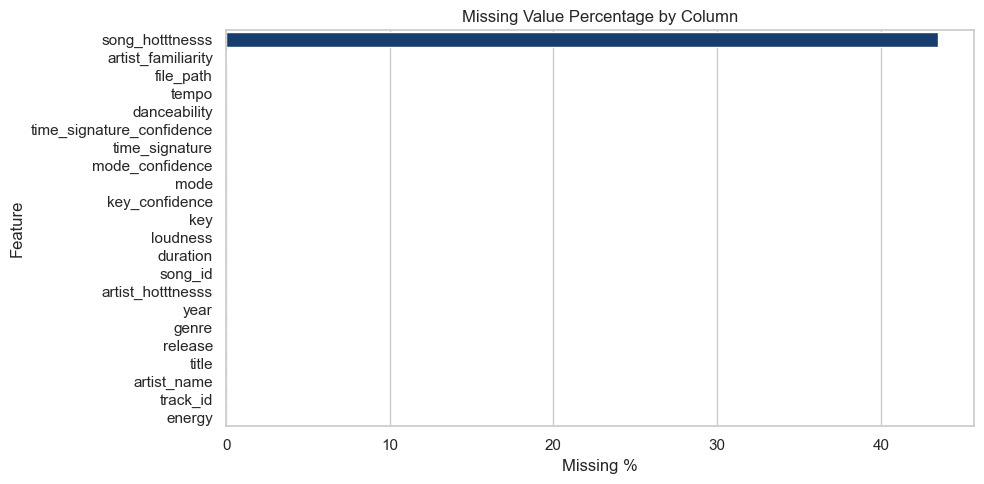

In [4]:
missing_pct = df.isna().mean().sort_values(ascending=False) * 100
missing_report = pd.DataFrame({'missing_percent': missing_pct})
display(missing_report.head(15))

plt.figure(figsize=(10, 5))
sns.barplot(x=missing_pct.values, y=missing_pct.index, palette='Blues_r')
plt.title('Missing Value Percentage by Column')
plt.xlabel('Missing %')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 5. Missing Value Management
This block applies practical imputation: numeric columns use median (robust to skew/outliers), while categorical columns use most frequent value.

In [5]:
df_clean = df.copy()

num_cols = df_clean.select_dtypes(include=['number']).columns
cat_cols = df_clean.select_dtypes(include=['object']).columns

for c in num_cols:
    if df_clean[c].isna().any():
        df_clean[c] = df_clean[c].fillna(df_clean[c].median())

for c in cat_cols:
    if df_clean[c].isna().any():
        mode_val = df_clean[c].mode(dropna=True)
        fill_val = mode_val.iloc[0] if len(mode_val) else 'Unknown'
        df_clean[c] = df_clean[c].fillna(fill_val)

print('Remaining missing values:', int(df_clean.isna().sum().sum()))

Remaining missing values: 0


## 6. EDA Operation 2: Distribution and Outlier Check
This operation visualizes key feature distributions and outliers. Understanding spread helps justify scaling and robust modeling choices.

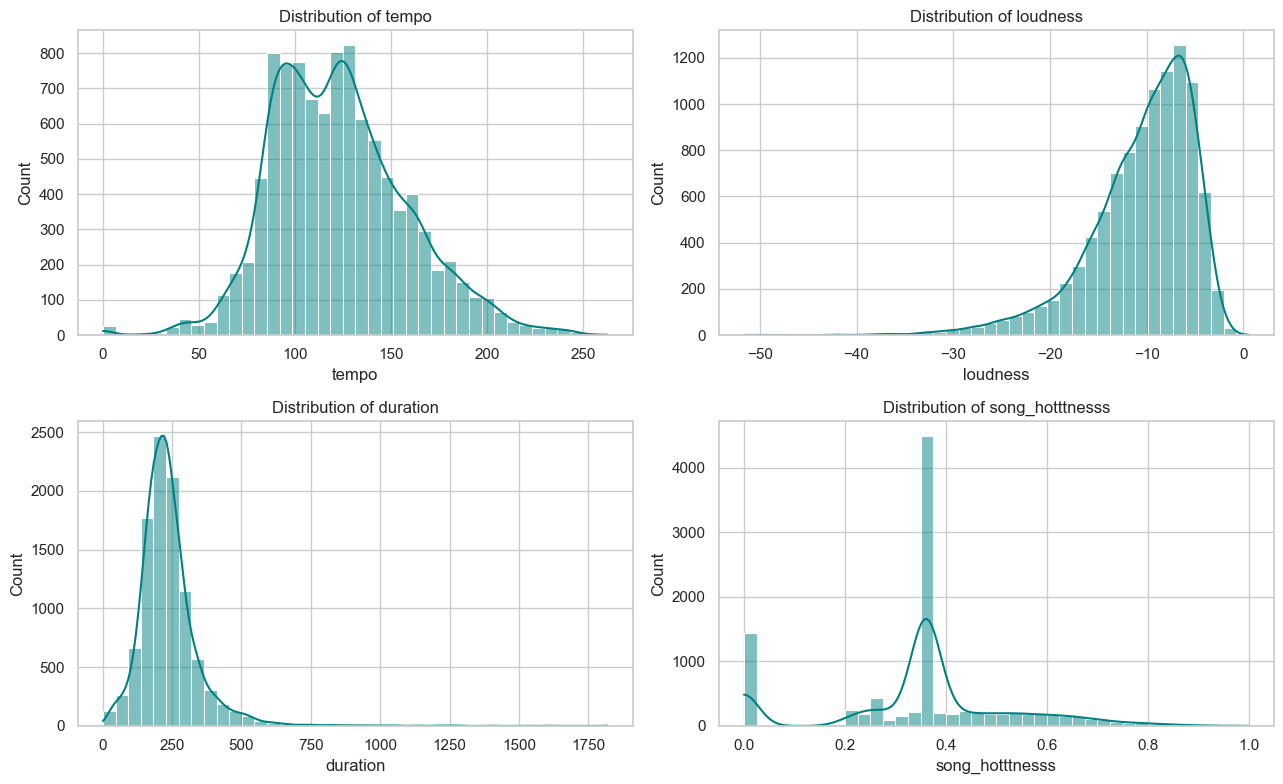

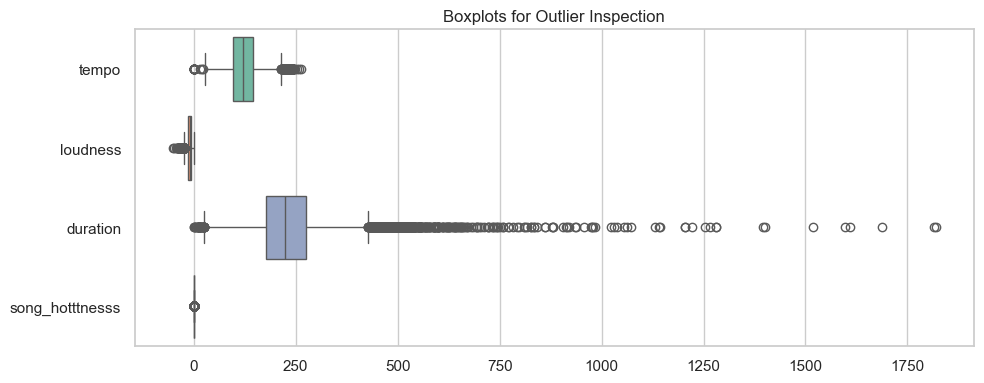

In [6]:
eda_features = ['tempo', 'loudness', 'duration', 'song_hotttnesss']

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col in zip(axes.flat, eda_features):
    sns.histplot(df_clean[col], kde=True, bins=40, ax=ax, color='teal')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.boxplot(data=df_clean[eda_features], orient='h', palette='Set2')
plt.title('Boxplots for Outlier Inspection')
plt.tight_layout()
plt.show()

## 7. EDA Operation 3: Pearson Correlation (Definition + Heatmap + Interpretation)
Pearson correlation coefficient measures linear association between two numeric variables and ranges from -1 to +1.

- +1: perfect positive linear relation
- 0: no linear relation
- -1: perfect negative linear relation

This heatmap helps identify redundant features and informs feature selection.

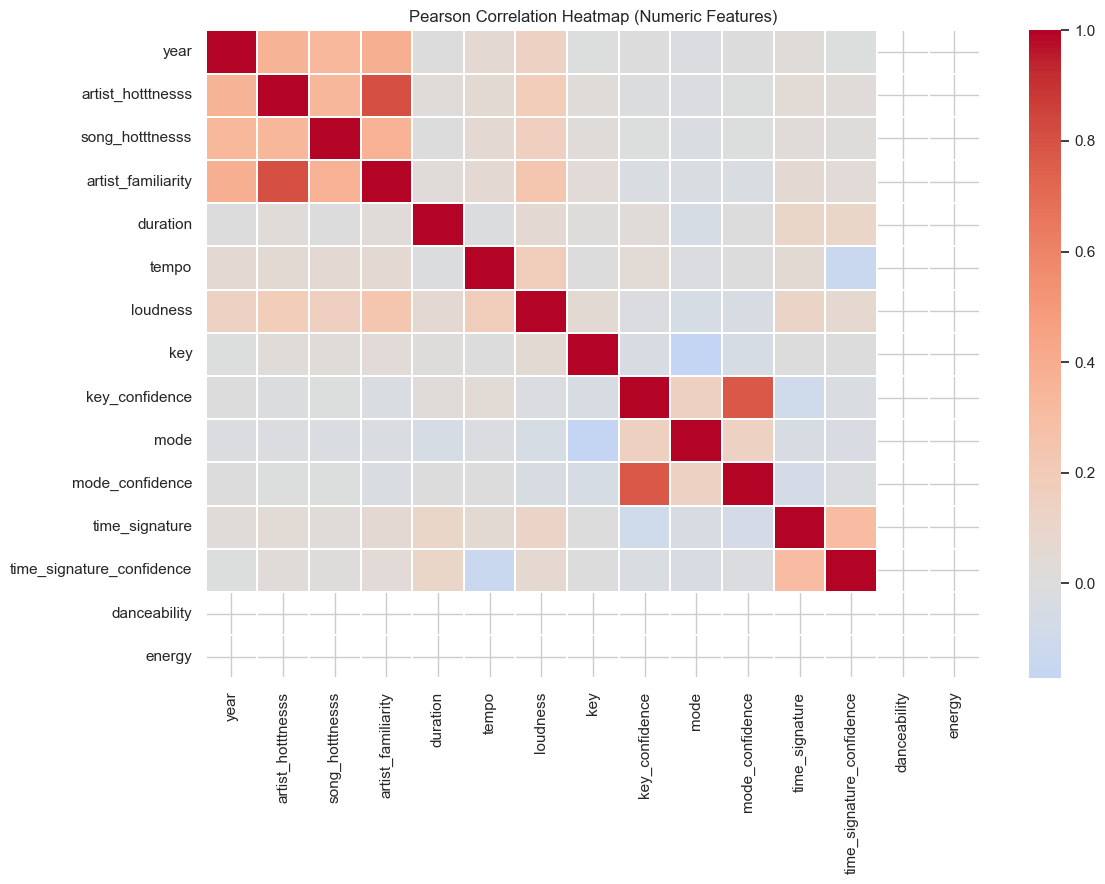

,pearson_with_song_hotttnesss
artist_familiarity,0.375149
artist_hotttnesss,0.339809
year,0.327792
loudness,0.158170
tempo,0.058052
time_signature,0.028578
mode,-0.027942
key,0.019583
time_signature_confidence,0.014231
duration,0.004280


In [7]:
corr = df_clean.select_dtypes(include=['number']).corr(method='pearson')

plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.2)
plt.title('Pearson Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.show()

target_for_corr = 'song_hotttnesss'
corr_to_target = corr[target_for_corr].drop(target_for_corr).sort_values(key=np.abs, ascending=False)
display(corr_to_target.to_frame('pearson_with_song_hotttnesss').head(12))

## 8. Build a Supervised Target for Validation Tasks
To satisfy imbalance handling, train-test split, and K-fold evaluation, we define a binary target `is_popular` from song hotness.

Rule used here: top 25% by `song_hotttnesss` is class 1, others class 0. This intentionally creates imbalance for resampling demonstration.

Class distribution before resampling:
is_popular
0    7499
1    2501
Name: count, dtype: int64


/var/folders/hl/110lkfyx5nz36v12z89t8gfr0000gn/T/ipykernel_52779/1868373047.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_popular', data=df_clean, palette='viridis')


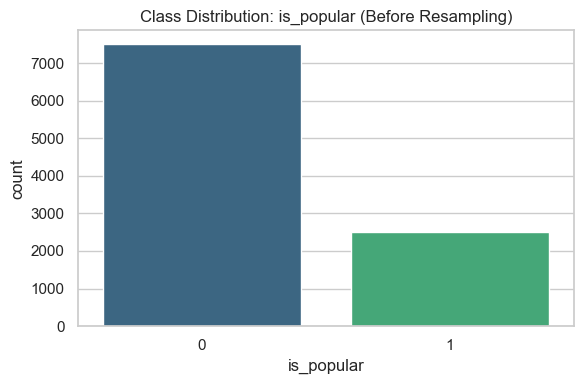

In [8]:
q75 = df_clean['song_hotttnesss'].quantile(0.75)
df_clean['is_popular'] = (df_clean['song_hotttnesss'] >= q75).astype(int)

class_counts = df_clean['is_popular'].value_counts().sort_index()
print('Class distribution before resampling:')
print(class_counts)

plt.figure(figsize=(6, 4))
sns.countplot(x='is_popular', data=df_clean, palette='viridis')
plt.title('Class Distribution: is_popular (Before Resampling)')
plt.tight_layout()
plt.show()

## 9. Feature Engineering
This block performs two required operations:
1. Categorical to numeric conversion using one-hot encoding (`key`, `mode`, `time_signature`).
2. Feature scaling using `StandardScaler` for continuous features.

Feature set is guided by Pearson relevance and domain understanding.

In [9]:
selected_numeric = [
    'tempo', 'loudness', 'duration', 'artist_hotttnesss',
    'artist_familiarity', 'key_confidence', 'mode_confidence',
    'time_signature_confidence', 'danceability', 'energy'
]
selected_categorical = ['key', 'mode', 'time_signature']

X = df_clean[selected_numeric + selected_categorical].copy()
y = df_clean['is_popular'].copy()

print('Feature matrix shape:', X.shape)
print('Target shape:', y.shape)

Feature matrix shape: (10000, 13)
Target shape: (10000,)


## 10. Training-Test Split
We split the data into train and test sets using stratification so class proportions are preserved in both sets.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)
print('Train class distribution:\n', y_train.value_counts(normalize=True).sort_index())
print('Test class distribution:\n', y_test.value_counts(normalize=True).sort_index())

Train shape: (8000, 13) Test shape: (2000, 13)
Train class distribution:
 is_popular
0    0.749875
1    0.250125
Name: proportion, dtype: float64
Test class distribution:
 is_popular
0    0.75
1    0.25
Name: proportion, dtype: float64


## 11. Manage Imbalance (Oversampling on Training Set Only)
To prevent data leakage, oversampling is applied only on `X_train, y_train`. The test set remains untouched for fair evaluation.

In [11]:
ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

print('Class distribution after oversampling:')
print(y_train_res.value_counts().sort_index())

Class distribution after oversampling:
is_popular
0    5999
1    5999
Name: count, dtype: int64


## 12. Model Pipeline + K-Fold Cross-Validation
A full preprocessing + model pipeline is used to avoid leakage and ensure reproducibility.

K-fold (stratified) cross-validation estimates performance stability across folds rather than relying on a single split.

In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), selected_numeric),
        ('cat', OneHotEncoder(handle_unknown='ignore'), selected_categorical),
    ]
)

pipeline = Pipeline(steps=[
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=1200, random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X_train_res, y_train_res, cv=cv, scoring='roc_auc')

print('5-Fold ROC-AUC scores:', np.round(cv_scores, 4))
print('Mean ROC-AUC:', round(cv_scores.mean(), 4))
print('Std ROC-AUC:', round(cv_scores.std(), 4))

5-Fold ROC-AUC scores: [0.7815 0.7624 0.7684 0.7896 0.7779]
Mean ROC-AUC: 0.776
Std ROC-AUC: 0.0096


/Users/vikdayal/pred2/predictive2/ProjectMSD/.venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/vikdayal/pred2/predictive2/ProjectMSD/.venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/vikdayal/pred2/predictive2/ProjectMSD/.venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/vikdayal/pred2/predictive2/ProjectMSD/.venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/vikdayal/pred2/predictive2/ProjectMSD/.venv/lib/python3.10/site-packages/sklearn/linear_model/_linea

## 13. Final Test Evaluation
This final step fits on the balanced training set and evaluates on untouched test data to report realistic generalization performance.

              precision    recall  f1-score   support

           0     0.8651    0.7053    0.7771      1500
           1     0.4311    0.6700    0.5247       500

    accuracy                         0.6965      2000
   macro avg     0.6481    0.6877    0.6509      2000
weighted avg     0.7566    0.6965    0.7140      2000

Test ROC-AUC: 0.7656


/Users/vikdayal/pred2/predictive2/ProjectMSD/.venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/vikdayal/pred2/predictive2/ProjectMSD/.venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/vikdayal/pred2/predictive2/ProjectMSD/.venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/vikdayal/pred2/predictive2/ProjectMSD/.venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/vikdayal/pred2/predictive2/ProjectMSD/.venv/lib/python3.10/site-packages/sklearn/linear_model/_linea

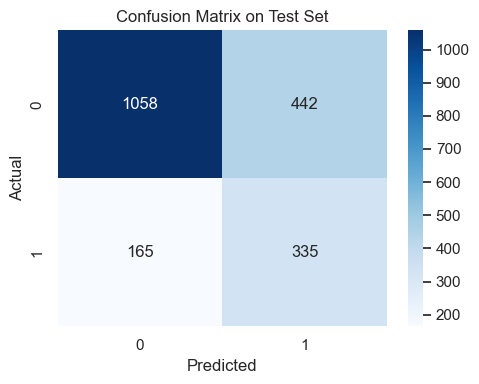

In [13]:
pipeline.fit(X_train_res, y_train_res)
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, digits=4))
print('Test ROC-AUC:', round(roc_auc_score(y_test, y_proba), 4))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix on Test Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 14. Deliverable Export (Optional)
Use this block to save the cleaned dataset used in Phase 2 so it can be added to your final submission ZIP alongside this notebook.

In [14]:
output_path = Path('phase2_cleaned_dataset.csv')
df_clean.to_csv(output_path, index=False)
print('Saved:', output_path.resolve())

Saved: /Users/vikdayal/pred2/predictive2/ProjectMSD/phase2_cleaned_dataset.csv
